## Task 1

c:\Users\RC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\RC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\RC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\RC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

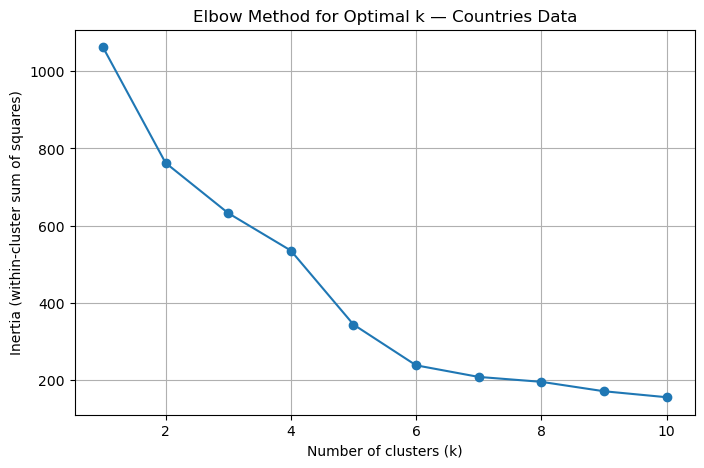

               country                      region  population       area  \
0          Afghanistan                  South Asia  38041754.0   652860.0   
1              Albania       Europe & Central Asia   2854191.0    28750.0   
2              Algeria  Middle East & North Africa  43053054.0  2381741.0   
3               Angola          Sub-Saharan Africa  31825295.0  1246700.0   
4  Antigua and Barbuda   Latin America & Caribbean     97118.0      440.0   

            gdp  life_expect  birth_rate  fertility_rate  death_rate  \
0    507.103432       64.833      31.802         61.3250       6.285   
1   5353.244856       78.573      11.620         19.5028       8.082   
2   3973.964072       76.880      23.583          9.5966       4.716   
3   2790.726615       61.147      40.232        145.3900       7.981   
4  17112.821130       77.016      15.107         40.8800       6.422   

   infant_mortality  Cluster  
0              46.5        0  
1               8.6        2  
2          

c:\Users\RC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("countries.csv")

# Select numeric columns useful for clustering
features = df[['population', 'gdp', 'life_expect', 'area', 'birth_rate', 'death_rate']].dropna()

scaler = StandardScaler()
X = scaler.fit_transform(features)

inertia = []
ks = range(1, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(ks, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k — Countries Data")
plt.grid(True)
plt.show()

optimal_k = 3  # Choose based on elbow curve
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X)

df_clustered = df.loc[features.index].copy()
df_clustered['Cluster'] = labels

print(df_clustered.head())
print("\nCluster counts:\n", df_clustered['Cluster'].value_counts())


## Task 2

Dataset Loaded Successfully!

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

Customer-level dataset:


,CustomerID,TotalItems,TotalSpent
0,12346.0,74215,77183.60
1,12347.0,2458,4310.00
2,12348.0,2341,1797.24
3,12349.0,631,1757.55
4,12350.0,197,334.40


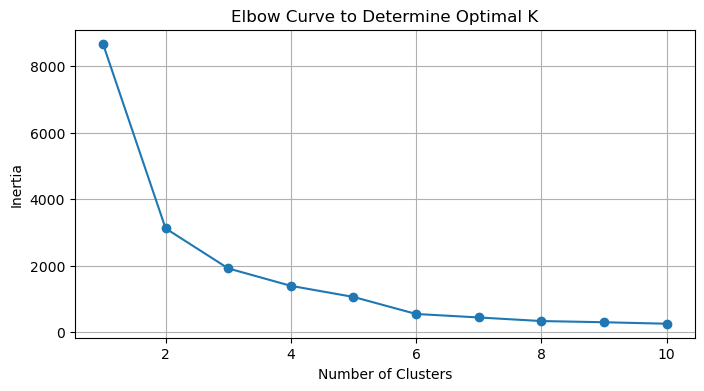

Choose the K value where the elbow shape appears (commonly 3 or 4).


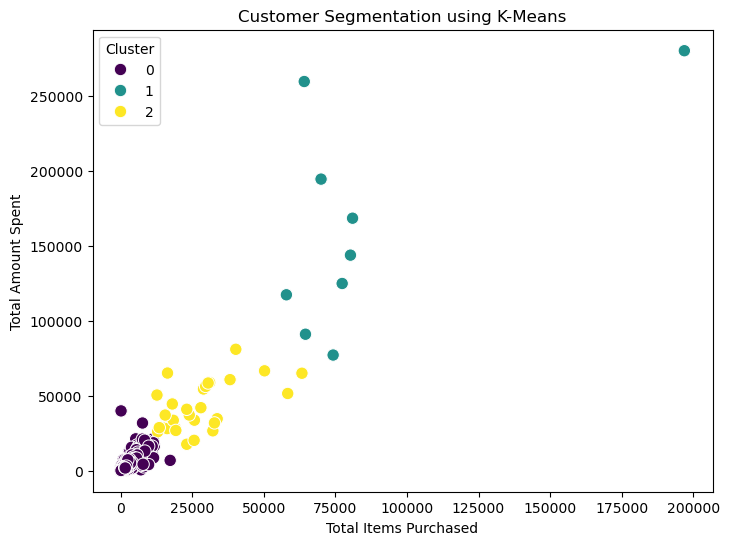


Cluster Summary:


,TotalItems,TotalSpent,NumCustomers
Cluster,,,
0,838.371860,1446.055506,4300
1,85146.333333,161916.867778,9
2,27465.379310,42624.738621,29



Interpretation Guide:

Cluster Characteristics May Look Like:
- Cluster 0: Low spenders, few items → Budget customers
- Cluster 1: Medium spenders, moderate items → Regular customers
- Cluster 2: High spenders, many items → Premium or loyal customers

Use these insights for:
- Targeted promotions
- Loyalty programs
- Personalized marketing
- Identifying high-value customers



In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load dataset


df = pd.read_excel("shopping_data.csv")
print("Dataset Loaded Successfully!")

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
print(df.info())


# 2. Basic Cleaning


df = df.dropna(subset=["CustomerID"])

df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

# 3. Feature Engineering for Clustering
# We need: 
#   - Total amount spent per customer
#   - Total number of items purchased per customer

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

customer_data = df.groupby("CustomerID").agg({
    "Quantity": "sum",
    "TotalPrice": "sum"
}).reset_index()

customer_data.rename(columns={
    "Quantity": "TotalItems",
    "TotalPrice": "TotalSpent"
}, inplace=True)

print("\nCustomer-level dataset:")
display(customer_data.head())

# 4. Select Features

X = customer_data[["TotalItems", "TotalSpent"]]

# 5. Standardize Features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Elbow Method to find optimal K

inertia_values = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K_range, inertia_values, marker='o')
plt.title("Elbow Curve to Determine Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

print("Choose the K value where the elbow shape appears (commonly 3 or 4).")

# 7. Apply K-Means Clustering

optimal_k = 3  
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

customer_data["Cluster"] = clusters

# 8. Visualize Clusters

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=customer_data,
    x="TotalItems",
    y="TotalSpent",
    hue="Cluster",
    palette="viridis",
    s=80
)
plt.title("Customer Segmentation using K-Means")
plt.xlabel("Total Items Purchased")
plt.ylabel("Total Amount Spent")
plt.show()

# 9. Analyze Clusters

cluster_summary = customer_data.groupby("Cluster").agg({
    "TotalItems": "mean",
    "TotalSpent": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "NumCustomers"})

print("\nCluster Summary:")
display(cluster_summary)

print("\nInterpretation Guide:")
print("""
Cluster Characteristics May Look Like:
- Cluster 0: Low spenders, few items → Budget customers
- Cluster 1: Medium spenders, moderate items → Regular customers
- Cluster 2: High spenders, many items → Premium or loyal customers

Use these insights for:
- Targeted promotions
- Loyalty programs
- Personalized marketing
- Identifying high-value customers
""")


## Task 3

In [ ]:
# Task 3: PCA on Financial Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load the financial dataset
df = pd.read_csv("financial_data.csv")
print("Dataset Loaded Successfully!\n")
print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nDataset Description:\n", df.describe())

# 2. Select relevant numeric features for PCA
features = ['Income', 'Spending', 'Savings', 'Investments']
financial_data = df[features].dropna()  # drop missing values
print(f"\nSelected features for PCA:\n{financial_data.head()}")

# 3. Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(financial_data)
print("\nFeatures standardized.")

# 4. Apply PCA
pca = PCA()
pca_data = pca.fit(scaled_data)

# 5. Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance Ratio of each principal component:\n", explained_variance)
print("\nCumulative Explained Variance:\n", cumulative_variance)

# 6. Determine number of components to retain 
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of principal components to retain 95% variance: {n_components}")

# 7. Transform the data using selected components
pca_final = PCA(n_components=n_components)
reduced_data = pca_final.fit_transform(scaled_data)
print(f"\nShape of reduced data: {reduced_data.shape}")

# 8. Create a DataFrame for transformed data
reduced_df = pd.DataFrame(reduced_data, columns=[f'PC{i+1}' for i in range(n_components)])
print("\nReduced-dimensional representation (first 5 rows):\n", reduced_df.head())

# 9. Visualize explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# 10. Insights (example)
print("\nInsights:")
for i in range(n_components):
    print(f"PC{i+1} explains {explained_variance[i]*100:.2f}% of variance.")

print("\nRecommendation: Use the reduced data for further analysis, clustering, or visualization to understand underlying financial behavior patterns without losing significant information.")


FileNotFoundError: [Errno 2] No such file or directory: 'financial_data.csv'